# Enzyme-Linked Immunosorbent Assay (ELISA)

## Objective & Background
To determine the antigen concentrations of our experimental samples, we perform an Enzyme-Linked Immunosorbent Assay (ELISA) utilizing microplate strips to analyze specific Influenza A viral markers.

---

> **Analytical Strategy:** As the antigen-antibody complexes bind across a gradient of standards, the chromogenic substrate reaction generates an optical density directly related to viral load, naturally following non-linear sigmoidal kinetics. This notebook will model a **4-Parameter Logistic (4PL) Non-Linear Curve Fit** to construct the calibration curve which we can use to accurately calculate the antigen concentrations of our unknown samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
#Standard reference antigen concentrations sorted ascending for interpolation(Microgram per milliliter, µg/ml)
conc = np.array([6.25, 12.5, 25, 50, 100, 200])

#Observed absorbance of standard reference samples (A)
absorbance = np.array([0.14, 0.28, 0.58, 0.91, 1.65, 2.10])

#Observed rocket height of experimental samples (A)
s_absorbance = np.array([0.82, 1.45])

In [3]:
#Define the formula for 4-Parameter Logistic Regression
def formula_4pl(x, A, B, C, D):
    return D + (A - D) / (1.0 + (x / C) ** B)

#curve_fit needs initial guesses [A, B, C, D] to start optimizing efficiently
initial_guesses = [0.05, 1.0, 50.0, 2.5]

#Fit the parameters using non-linear least squares
params, covariance = curve_fit(
    formula_4pl, conc, absorbance, p0=initial_guesses
)
A_fit, B_fit, C_fit, D_fit = params

In [4]:
#Inverting the 4PL equation to solve for concentration given absorbance
def invert_4pl(y, A, B, C, D):
    return C * (((A - D) / (y - D)) - 1.0) ** (1.0 / B)

In [5]:
# Calculate using 4PL curve_fit
conc_4pl = invert_4pl(s_absorbance, A_fit, B_fit, C_fit, D_fit)

print(f"Sample A, Absorbance {s_absorbance[0]}, Concentration {conc_4pl[0]:.2f}%")
print(f"Sample B, Absorbance {s_absorbance[1]}, Concentration {conc_4pl[1]:.2f}%")

Sample A, Absorbance 0.82, Concentration 40.32%
Sample B, Absorbance 1.45, Concentration 84.56%


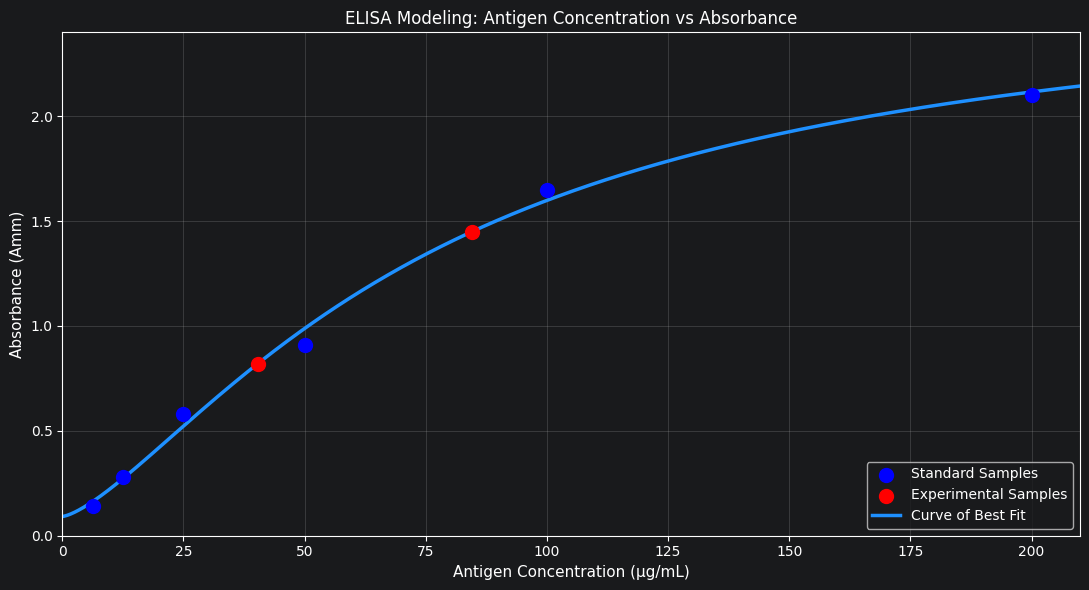

In [6]:
#Linear Plot
x_smooth = np.linspace(0, 210, 1000)
y_smooth_spline = np.linspace(absorbance.min(), absorbance.max(), 1000)

plt.figure(figsize=(11, 6))

#Plot scatter points of standard sample data
plt.scatter(
    conc,
    absorbance,
    color="blue",
    s=100,
    zorder=5,
    label = "Standard Samples",
)

#Plot scatter points of experimental sample data
plt.scatter(
    conc_4pl,
    s_absorbance,
    color = "red",
    s = 100,
    zorder = 5,
    label = "Experimental Samples"
)

#Plot 4PL curve_fit line
plt.plot(
    x_smooth,
    formula_4pl(x_smooth, *params),
    color = "dodgerblue",
    linestyle = "-",
    linewidth = 2.5,
    label = "Curve of Best Fit",
)

#Plot formatting
plt.title("ELISA Modeling: Antigen Concentration vs Absorbance",)
plt.xlabel("Antigen Concentration (µg/mL)", fontsize=11)
plt.ylabel("Absorbance (Amm)", fontsize=11)
plt.xlim(0, 210)
plt.ylim(0, absorbance.max() + 0.3)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()

plt.show()